In [13]:
from skykatana import SkyMaskPipe   #skykatanaV02
import healpy as hp, healsparse as hsp, pandas as pd
from mocpy import MOC, WCS
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from functools import partial
import lsdb

In [2]:
# Start dask client ---------------
from dask.distributed import Client
client = Client(n_workers=3, threads_per_worker=1, memory_limit="6GiB")

-------------------------
# Creating Star Masks in RSP with Skykatana

## 1. Create pipeline and define search area

**First we have to define a seach area where to look for stars. While it can be any stage or boolean map, in Rubin it will be most likely some property map for example of coverage or total exposure time in a given band**

In [2]:
# Instantiate the pipline
mkp = SkyMaskPipe(order_out=15)

# Create fake coverage and store in the propmask stage ------------------------------
ord_coverage = 5
ord_sparse   = 12 
moc1 = MOC.from_zone(SkyCoord([[237, -18], [15, 2]], unit="deg"), max_depth=ord_sparse)
moc2 = MOC.from_zone(SkyCoord([[15, -12], [20, 2]], unit="deg"), max_depth=ord_sparse)
moc3 = MOC.from_zone(SkyCoord([[20, -18], [30, 2]], unit="deg"), max_depth=ord_sparse)
moc = moc1.union(moc2).union(moc3)


mapbool = hsp.HealSparseMap.make_empty(2**ord_coverage, 2**ord_sparse, dtype=np.bool_)
pixels = moc.flatten().astype(np.int64)
mapbool.update_values_pix(pixels, True)
mkp.propmask = mapbool.as_bit_packed_map()

In [4]:
mkp

propmask       : (ord/nside)cov=5/32   (ord/nside)sparse=12/4096  valid_pix=14588203  area=2989.21 deg² pix_size=  51.5"

Looking pixels...
Found 14588203 pixels
Creating display moc from pixels...
MOC max_order is 12 --> degrading to 8...
Drawing plot...


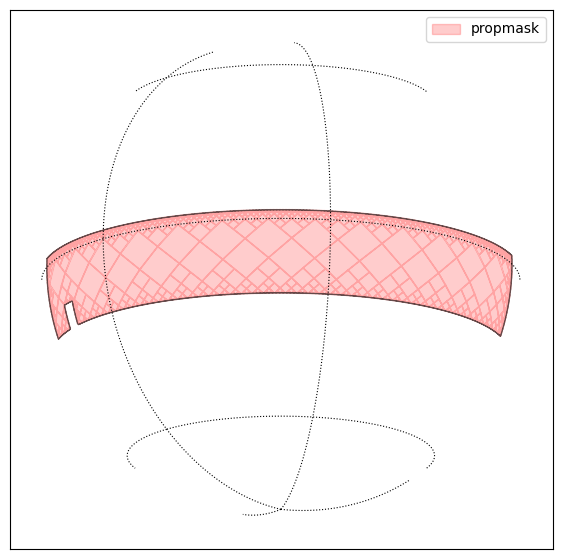

In [6]:
# Lets see how it looks in the sky -------------------------------------
center = SkyCoord(312*u.deg, -15*u.deg)  ;  fov = 130*u.deg
fig, ax, wcs = mkp.plot_moc(stage='propmask', center=center, fov=fov, figsize=[7,7], label='propmask', color='r')
plt.legend();

## 2. Define radius function and star query dictionary

In [6]:
# This function determines the radius of stars that will be masked. It can be completely customized according to band, 
# completeness level, or any other parameter. The only requirement is that it must take an input df (e.g. with 
# star magnitudes) and add a "radius" column (in deg)

def radfunction(df: pd.DataFrame, **kwargs):
    mag = 'phot_g_mean_mag'                          # define magnitude to use
    band = kwargs.get('band', 'r')                   # extract band
    completeness = kwargs.get('completeness', 0.85)  # extract completeness level
    if band == 'r':
        if completeness==0.85:
            nconst, alpha = (1234.7,-0.28)  # normalization constant and exponential slope alpha
            magcut        =  17.19          # magnitude cutoff above which stars get a fixed faint_radius
            faintrad      =  10.2           # faint radius [arcsec]
        elif completeness==0.90:
            nconst, alpha = (1318.6,-0.28)  # normalization constant and exponential slope alpha
            magcut        =  17.24          # magnitude cutoff above which stars get a fixed faint_radius
            faintrad      =  10.8           # faint radius [arcsec]
    # Set radius
    df['radius'] = np.where(df[mag] <= magcut, nconst*np.exp(alpha*df[mag])/3600., faintrad/3600.)

# Star query dictionary. This controls where and which stars will be queried, as well as some performance
# parameters to keep memory usage under control. If the area searched is very large, Skykatana can break
# it into chunks that are queried, processed and coadded at the end, enabling procesing of thousands of sq degrees

starq = {'search_stage': mkp.propmask,                 # The stage where we want to retrieve stars
         'cat':"https://data.lsdb.io/hats/gaia_dr3",   # URL of HATS catalog, e.g. for Gaia
         'columns':['ra','dec','phot_g_mean_mag'],     # Columns to retrieve from it
         'gaia_gmag_lims':[7,20],                      # G_band magnitude limits
         'radfunction': partial(radfunction, completeness=0.85, band='r'),  # Star radius function. Must be wrapped with partial()
         'avoid_mw': True,                             # Avoid Milky Way plane/bulge
         'b0_deg': 15.,                                # Mikly Way plane zone of exclusion from -b to b (deg)
         'bulge_a_deg': 25.,                           # Milky Way bulge semimajor axis length (deg)  
         'bulge_b_deg': 20.,                           # Milky Way bulge semiminor axis length (deg)
         'max_area_single': 700.,                         # Optional - max area to make in a single query
         'target_chunk_area': 700.,                       # Optional - target area of chuncks that the search_stage is splitted
         'coarse_order_bfs': 5                            # Optional - coarse order to perform chunking
         }

## 3. Search stars, construct its mask and plot

In [7]:
mkp.build_star_mask_online(starq=starq, order_star=15, order_cov=5, n_threads=1);

BUILDING STAR MASK >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
--- Avoid Milky Way is ON
Area of search_stage is 2291.43 deg2 -> splitting...
Got 3 chunks of areas [662.57 701.23 1115.05] deg²
Chunk 1/3: querying catalog ...
--- Stars found : 2335759
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_threads=1
    Circles to pixelate: 2335759 in batches of 600000
        processing circles 0:600000 ...
        processing circles 600000:1200000 ...
        processing circles 1200000:1800000 ...
        processing circles 1800000:2335759 ...
Chunk 2/3: querying catalog ...
--- Stars found : 1490778
--- Pixelating circles from DataFrame
    Order :: 15 | pixelization_threads=1
    Circles to pixelate: 1490778 in batches of 600000
        processing circles 0:600000 ...
        processing circles 600000:1200000 ...
        processing circles 1200000:1490778 ...
Chunk 3/3: querying catalog ...
--- Stars found : 14513982
--- Pixelating circles from DataFrame
    Order :: 15 | pix

In [8]:
mkp

propmask       : (ord/nside)cov=5/32   (ord/nside)sparse=12/4096  valid_pix=14588203  area=2989.21 deg² pix_size=  51.5"
starmask       : (ord/nside)cov=5/32   (ord/nside)sparse=15/32768 valid_pix=250859637  area=803.17 deg² pix_size=   6.4"

Looking pixels...
Found 250859637 pixels
Creating display moc from pixels...
MOC max_order is 15 --> degrading to 8...
Drawing plot...


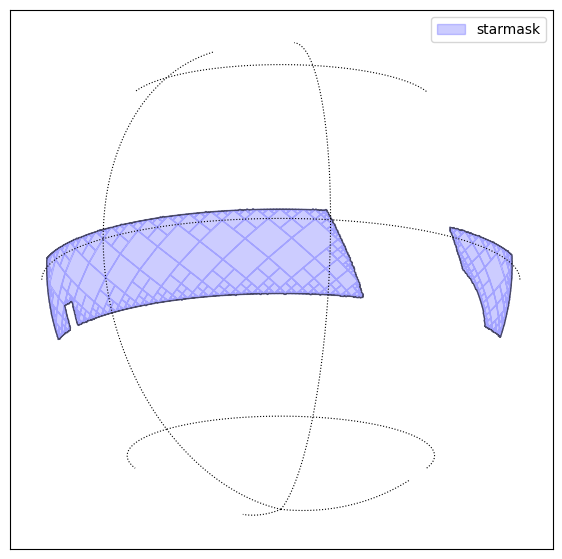

In [11]:
# Lets see how it looks in the sky -------------------------------------
center = SkyCoord(312*u.deg, -15*u.deg)  ;  fov = 130*u.deg
fig, ax, wcs = mkp.plot_moc(stage='starmask', center=center, fov=fov, figsize=[7,7], label='starmask', color='b')
plt.legend();

Looking pixels inside clip box...
Found 55786 pixels
Creating display moc from pixels...
MOC max_order is 15 --> no degrading...
Drawing plot...


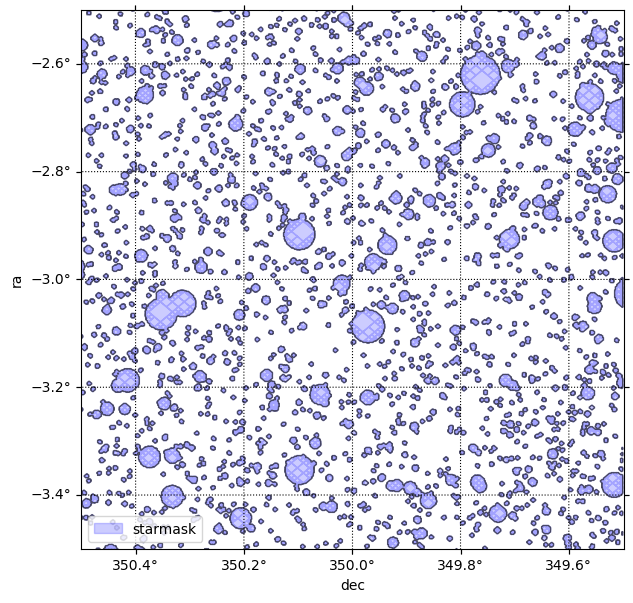

In [13]:
# Lets see how it looks in the sky -------------------------------------
center = SkyCoord(350*u.deg, -3*u.deg)  ;  fov = 1*u.deg
clipra = [350-0.5, 350+0.5]
clipdec = [-3-0.5, -3+0.5]
fig, ax, wcs = mkp.plot_moc(stage='starmask', center=center, fov=fov, figsize=[7,7], color='b', label='starmask',
                            clipra=clipra, clipdec=clipdec)
plt.legend();

## 4. Combine and save to disk

In [14]:
mkp.combine(positive=['propmask'], negative=['starmask'], order_out=15, order_cov=5);

[combine] aligning coverage for 'propmask' : c5 → c5
[combine] aligning coverage for 'starmask' : c5 → c5
[combine] target=(o15, c5), work_order=12, r2=64
[combine:+] stage at order 12 -> work 12
[combine] done: order_out=15 (NSIDE=32768), order_cov=5 (NSIDE=32), valid_pix=686,838,744, area=2199.018 deg², bit_packed=True


In [15]:
mkp

propmask       : (ord/nside)cov=5/32   (ord/nside)sparse=12/4096  valid_pix=14588203  area=2989.21 deg² pix_size=  51.5"
starmask       : (ord/nside)cov=5/32   (ord/nside)sparse=15/32768 valid_pix=250859637  area=803.17 deg² pix_size=   6.4"
mask           : (ord/nside)cov=5/32   (ord/nside)sparse=15/32768 valid_pix=686838744  area=2199.02 deg² pix_size=   6.4"

In [ ]:
# Write the entire mask in a single statement
mkp.write(outdir='./test3000', overwrite=True)

## 5. Read and plot final mask

In [2]:
mkp = SkyMaskPipe.read(indir='./test3000')

[read] Loading mask  <- mask.fits
[read] Loading propmask  <- propmask.fits
[read] Loading starmask  <- starmask.fits
[read] Done  propmask  (nside_cov=32, nside_sparse=4096, n_valid=14588203)
[read] Done  starmask  (nside_cov=32, nside_sparse=32768, n_valid=250859637)
[read] Done  mask  (nside_cov=32, nside_sparse=32768, n_valid=686838744)
[read] All stages attached.


In [3]:
mkp

propmask       : (ord/nside)cov=5/32   (ord/nside)sparse=12/4096  valid_pix=14588203  area=2989.21 deg² pix_size=  51.5"
starmask       : (ord/nside)cov=5/32   (ord/nside)sparse=15/32768 valid_pix=250859637  area=803.17 deg² pix_size=   6.4"
mask           : (ord/nside)cov=5/32   (ord/nside)sparse=15/32768 valid_pix=686838744  area=2199.02 deg² pix_size=   6.4"

In [4]:
mkp._params

{'starmask': {'area_deg2': 803.1650511706546,
  'avoid_mw': True,
  'b0_deg': 15.0,
  'bit_packed': None,
  'bulge_a_deg': 25.0,
  'bulge_b_deg': 20.0,
  'chunk_size': 600000,
  'columns': ['ra', 'dec', 'radius'],
  'n_threads': 1,
  'order_cov': 5,
  'order_star': 15,
  'pixels': 250859637,
  'starq': {'avoid_mw': True,
   'b0_deg': 15.0,
   'bulge_a_deg': 25.0,
   'bulge_b_deg': 20.0,
   'cat': 'https://data.lsdb.io/hats/gaia_dr3',
   'coarse_order_bfs': 5,
   'columns': ['ra', 'dec', 'phot_g_mean_mag'],
   'gaia_gmag_lims': [7, 20],
   'max_area_single': 700.0,
   'radfunction': "functools.partial(<function radfunction at 0x7be8ac62b240>, completeness=0.85, band='r')",
   'search_stage': '<dummy>',
   'target_chunk_area': 700.0}}}

Looking pixels inside clip box...
Found 22813940 pixels
Creating display moc from pixels...
MOC max_order is 15 --> degrading to 12...
Drawing plot...


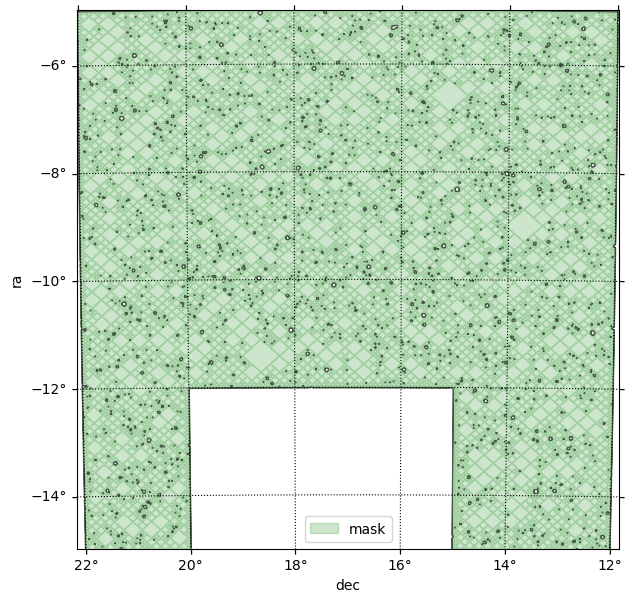

In [5]:
center = SkyCoord(17*u.deg, -10*u.deg)  ;  fov = 10*u.deg
clipra  = [17-5, 17+5]
clipdec = [-10-5, -10+5]
fig, ax, wcs = mkp.plot_moc(stage='mask', center=center, fov=fov, figsize=[7,7], label='mask', color='g',
                            clipra=clipra, clipdec=clipdec)
plt.legend();

-----------------------
**Skykatana can also generate interactive plots of masks by leveraging the Jupyterlab widget of ``ipyaladin``**

In [4]:
# Over the GAIA density map, overlay the starmask degraded to order 13 to save time. Small circles will wash out 
# but we are aiming for a large scale visualization. Note how the starmask has avoided the galactic plane 
# and bulge because we set avoid_mw=True
alawidget = mkp.plot_moca(mkp.starmask, order_forced=13)

Aladin()

Retrieveing 250859637 pixels...
Building MOC at order 13...
Adding MOC to widget...


**Note you should degrade very large masks (thousands of sq degrees) of high order (15-16). Otherwise the widget will receive a huge MOC and might become unresponsive. Best practice is to force a low order first, and then rise it untill satisfied.**

**Once a widget is generated with ``plot_moca()``, use ``add_moca()`` to overlay another mask on top of it** --> SkyMaskPipe.add_moca(alawidget, mkp.extramask, color='yellow')

**Below is a screen capture of the plot produced above**

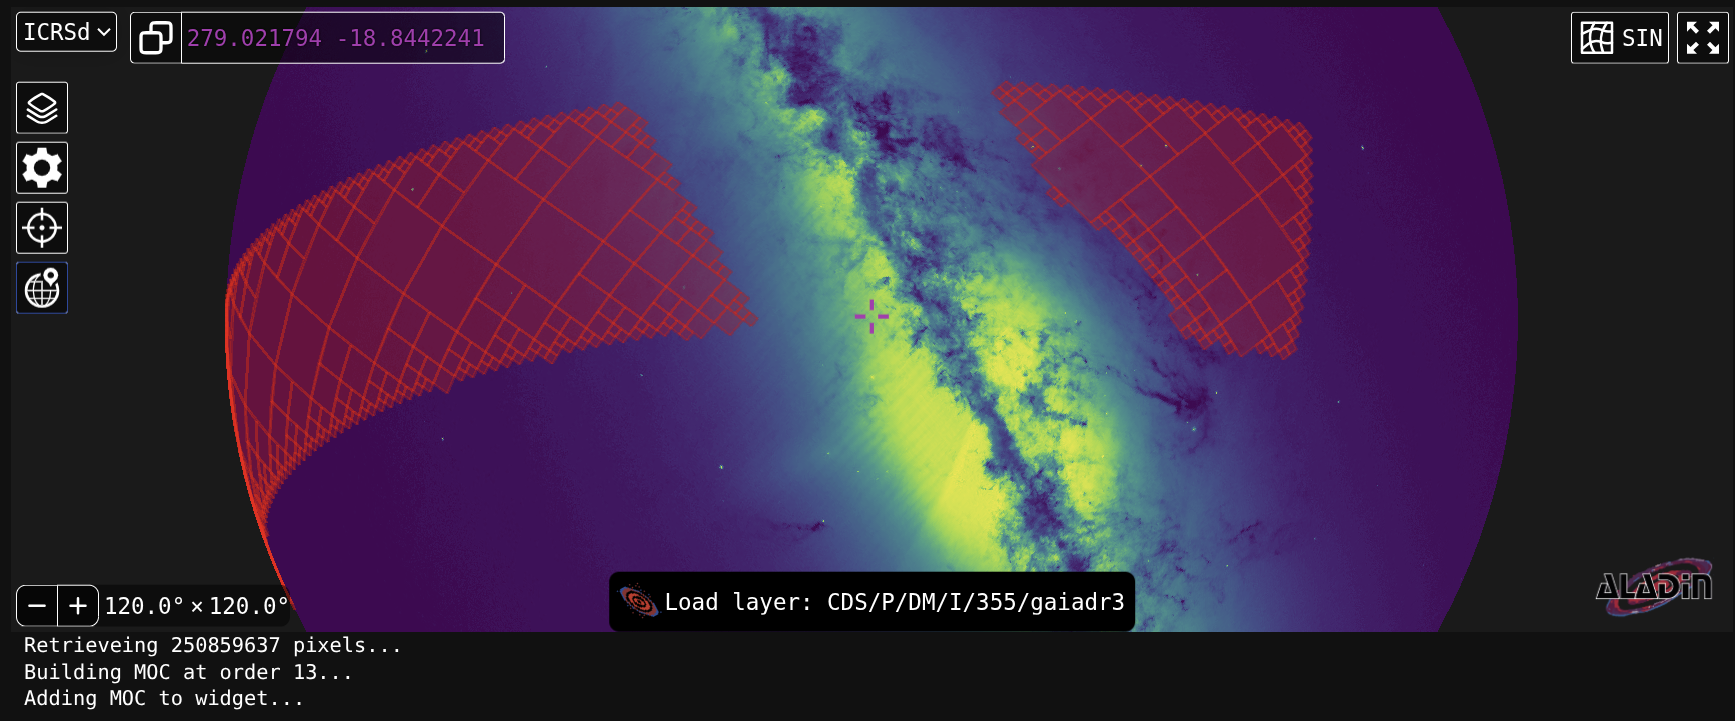